# Import Packages

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
from torchinfo import summary
from tqdm.auto import tqdm

import os
import math

/mnt/d/Learn/.gen_ai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

In [2]:
T = 1000
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_cumprod = torch.cumprod(alpha, dim=0)
sqrt_acp = torch.sqrt(alpha_cumprod)
sqrt_omacp = torch.sqrt(1 - alpha_cumprod)

image_size = 128  # the generated image resolution
train_batch_size = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dataloader

In [3]:
dataset_name = "huggan/smithsonian_butterflies_subset"
dataset = load_dataset(dataset_name, split="train")

Repo card metadata block was not found. Setting CardData to empty.


/tmp/ipykernel_53336/2340717843.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


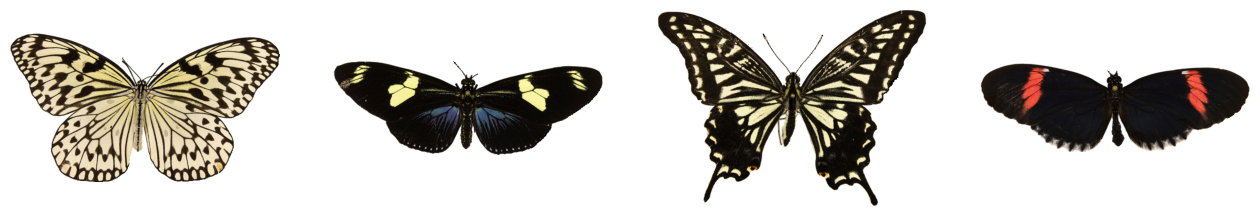

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

In [5]:
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ]
)

In [6]:
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

In [7]:
train_dataloader = torch.utils.data.DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

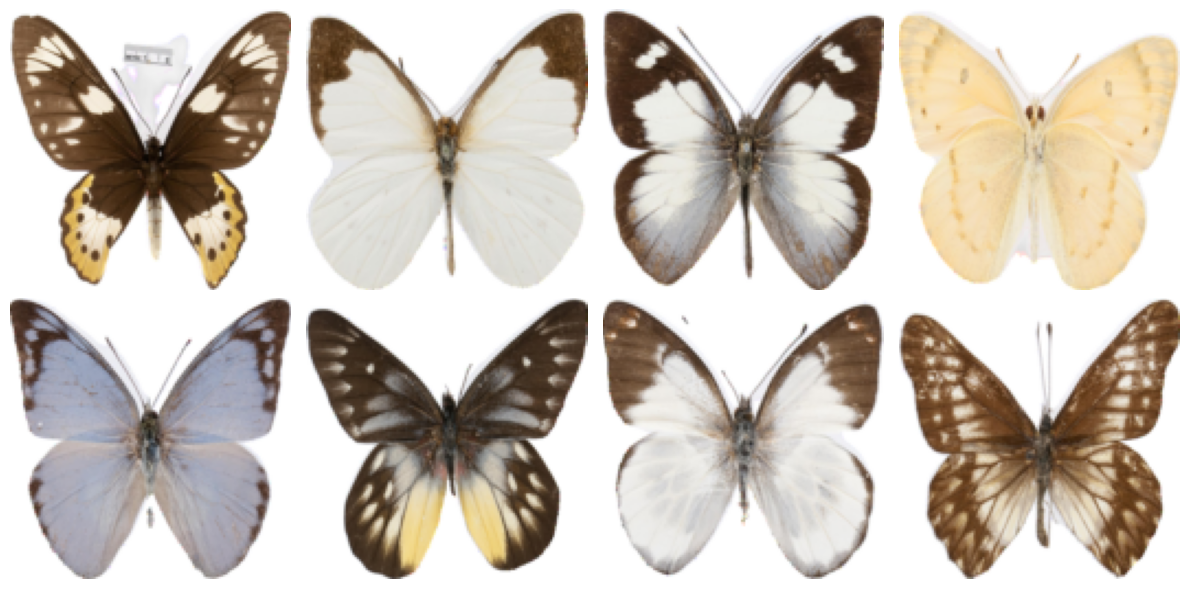

In [8]:
batch = next(iter(train_dataloader))
images = batch["images"][:8].cpu()   # [8,3,H,W]

plt.figure(figsize=(12, 6))

for i in range(8):
    img = images[i]

    # denormalize: [-1,1] → [0,1]
    img = (img * 0.5) + 0.5

    img = img.permute(1, 2, 0)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Model

## U-Net

In [9]:
# ----------------------------
# Sinusoidal timestep embedding
# ----------------------------
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: [B] long/float tensor of timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)   # [B, half]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)  # [B, dim]
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


# ----------------------------
# Time-conditioned ResNet block with GroupNorm + Dropout
# ----------------------------
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, time_dim, groups=8, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(min(groups, in_c), in_c)
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_c)  # FiLM-style additive conditioning

        self.norm2 = nn.GroupNorm(min(groups, out_c), out_c)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)

        self.skip = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]   # inject time info
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


# ----------------------------
# Self-attention block (used at lower resolutions only)
# ----------------------------
class AttnBlock(nn.Module):
    def __init__(self, channels, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(min(groups, channels), channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]          # each [B, C, HW]
        attn = torch.softmax((q.transpose(1, 2) @ k) / math.sqrt(C), dim=-1)  # [B,HW,HW]
        out = (v @ attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)


# ----------------------------
# Down / Up sampling with learnable parameters
# ----------------------------
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.op = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


# ----------------------------
# Full U-Net with GroupNorm, Dropout, multi-ResBlock stages,
# attention at low resolution, learnable down/up-sampling,
# and explicit timestep conditioning
# ----------------------------
class UNet3ch(nn.Module):
    def __init__(self, base_ch=64, time_dim=256, layers_per_block=2, dropout=0.1):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(base_ch),
            nn.Linear(base_ch, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.in_conv = nn.Conv2d(3, base_ch, 3, padding=1)

        # ---- Encoder ----
        self.enc1 = nn.ModuleList([ResBlock(base_ch, base_ch, time_dim, dropout=dropout)
                                    for _ in range(layers_per_block)])
        self.down1 = Downsample(base_ch)

        self.enc2 = nn.ModuleList([ResBlock(base_ch if i == 0 else base_ch*2, base_ch*2, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.down2 = Downsample(base_ch*2)

        self.enc3 = nn.ModuleList([ResBlock(base_ch*2 if i == 0 else base_ch*4, base_ch*4, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.attn3 = AttnBlock(base_ch*4)         # attention at the lower resolution
        self.down3 = Downsample(base_ch*4)

        # ---- Bottleneck ----
        self.bottleneck1 = ResBlock(base_ch*4, base_ch*8, time_dim, dropout=dropout)
        self.bottleneck_attn = AttnBlock(base_ch*8)
        self.bottleneck2 = ResBlock(base_ch*8, base_ch*8, time_dim, dropout=dropout)

        # ---- Decoder ----
        self.up3 = Upsample(base_ch*8)
        self.dec3 = nn.ModuleList([ResBlock(base_ch*8 + base_ch*4 if i == 0 else base_ch*4, base_ch*4, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])
        self.dec3_attn = AttnBlock(base_ch*4)

        self.up2 = Upsample(base_ch*4)
        self.dec2 = nn.ModuleList([ResBlock(base_ch*4 + base_ch*2 if i == 0 else base_ch*2, base_ch*2, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])

        self.up1 = Upsample(base_ch*2)
        self.dec1 = nn.ModuleList([ResBlock(base_ch*2 + base_ch if i == 0 else base_ch, base_ch, time_dim, dropout=dropout)
                                    for i in range(layers_per_block)])

        self.out_norm = nn.GroupNorm(min(8, base_ch), base_ch)
        self.out_conv = nn.Conv2d(base_ch, 3, 3, padding=1)

    def _run_stage(self, blocks, x, t_emb):
        for blk in blocks:
            x = blk(x, t_emb)
        return x

    def forward(self, x, t):
        """
        x: [B,3,H,W]  noisy image only (time is NOT concatenated as a channel anymore)
        t: [B]        integer timesteps
        """
        t_emb = self.time_embed(t)

        h = self.in_conv(x)

        e1 = self._run_stage(self.enc1, h, t_emb)
        e2_in = self.down1(e1)
        e2 = self._run_stage(self.enc2, e2_in, t_emb)
        e3_in = self.down2(e2)
        e3 = self._run_stage(self.enc3, e3_in, t_emb)
        e3 = self.attn3(e3)
        b_in = self.down3(e3)

        b = self.bottleneck1(b_in, t_emb)
        b = self.bottleneck_attn(b)
        b = self.bottleneck2(b, t_emb)

        d3_in = torch.cat([self.up3(b), e3], dim=1)
        d3 = self._run_stage(self.dec3, d3_in, t_emb)
        d3 = self.dec3_attn(d3)

        d2_in = torch.cat([self.up2(d3), e2], dim=1)
        d2 = self._run_stage(self.dec2, d2_in, t_emb)

        d1_in = torch.cat([self.up1(d2), e1], dim=1)
        d1 = self._run_stage(self.dec1, d1_in, t_emb)

        out = self.out_conv(F.silu(self.out_norm(d1)))
        return out

## DDPM

In [10]:
# ----------------------------
# 3. DDPM predicting x0, with 3-channel input
# ----------------------------
class DDPMx0_3ch(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = UNet3ch(base_ch=64)
        # register buffers so they move with .to(device)
        self.register_buffer('beta',          beta)
        self.register_buffer('alpha',         alpha)
        self.register_buffer('alpha_cumprod', alpha_cumprod)
        self.register_buffer('sqrt_acp',      sqrt_acp)
        self.register_buffer('sqrt_omacp',    sqrt_omacp)

    def q_sample(self, x0, t, noise):
        # x_t = √(ᾱ_t)·x0 + √(1−ᾱ_t)·noise
        return ( self.sqrt_acp[t].view(-1,1,1,1)*x0
               + self.sqrt_omacp[t].view(-1,1,1,1)*noise )

    def forward(self, x0, t):
        noise = torch.randn_like(x0)
        x_t   = self.q_sample(x0, t, noise)
        x0_hat = self.unet(x_t, t)
        return F.mse_loss(x0_hat, x0)

## Summary

In [11]:
model = DDPMx0_3ch().to(device)

# Get one sample from train loader
batch = next(iter(train_dataloader))
x0 = batch["images"][:1].to(device)   # [1,3,H,W]

# Create timestep
t = torch.tensor([0], device=device)

print("Original image shape :", x0.shape)
print("Timestep tensor       :", t.shape)

# Forward through UNet directly — time is now an embedding, not a concatenated channel
with torch.no_grad():
    out = model.unet(x0, t)

print("UNet output shape    :", out.shape)

Original image shape : torch.Size([1, 3, 128, 128])
Timestep tensor       : torch.Size([1])
UNet output shape    : torch.Size([1, 3, 128, 128])


In [12]:
summary(
    model.unet,
    input_data=[
        torch.randn(1, 3, image_size, image_size).to(device),
        torch.tensor([0]).to(device)
    ],
    device=device.type
)

Layer (type:depth-idx)                   Output Shape              Param #
UNet3ch                                  [1, 3, 128, 128]          --
├─Sequential: 1-1                        [1, 256]                  --
│    └─SinusoidalTimeEmbedding: 2-1      [1, 64]                   --
│    └─Linear: 2-2                       [1, 256]                  16,640
│    └─SiLU: 2-3                         [1, 256]                  --
│    └─Linear: 2-4                       [1, 256]                  65,792
├─Conv2d: 1-2                            [1, 64, 128, 128]         1,792
├─ModuleList: 1-3                        --                        --
│    └─ResBlock: 2-5                     [1, 64, 128, 128]         --
│    │    └─GroupNorm: 3-1               [1, 64, 128, 128]         128
│    │    └─Conv2d: 3-2                  [1, 64, 128, 128]         36,928
│    │    └─Linear: 3-3                  [1, 64]                   16,448
│    │    └─GroupNorm: 3-4               [1, 64, 128, 128]       

# Sampling / Inference

In [13]:
@torch.no_grad()
def sample(model, shape, device):
    """
    Correct DDPM ancestral sampling using the x0-prediction parameterization.

    Posterior q(x_{t-1} | x_t, x0):
        mean  = ( sqrt(alpha_t) * (1 - acp_{t-1}) / (1 - acp_t) ) * x_t
              + ( sqrt(acp_{t-1}) * beta_t        / (1 - acp_t) ) * x0_hat
        var   = (1 - acp_{t-1}) / (1 - acp_t) * beta_t
    """
    model.eval()
    x = torch.randn(shape, device=device)   # x_T ~ N(0, I), shape [B,3,H,W]
    B, _, H, W = shape

    alpha          = model.alpha
    alpha_cumprod  = model.alpha_cumprod
    beta           = model.beta

    for i in reversed(range(0, T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)

        x0_hat = model.unet(x, t)
        x0_hat = x0_hat.clamp(-1, 1)

        alpha_t   = alpha[i]
        acp_t     = alpha_cumprod[i]
        acp_prev  = alpha_cumprod[i - 1] if i > 0 else torch.tensor(1.0, device=device)
        beta_t    = beta[i]

        # posterior mean combines x_t and the x0 prediction
        coef_xt = (torch.sqrt(alpha_t) * (1 - acp_prev)) / (1 - acp_t)
        coef_x0 = (torch.sqrt(acp_prev) * beta_t) / (1 - acp_t)
        mean = coef_xt * x + coef_x0 * x0_hat

        if i > 0:
            var = (1 - acp_prev) / (1 - acp_t) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean   # no noise on the final step

    # x is in [-1,1]; rescale to [0,1] for display
    x = (x.clamp(-1, 1) + 1) / 2
    return x

# Train

In [ ]:
opt    = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 1000
losses = []

for ep in range(1, epochs+1):
    model.train()
    total = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {ep}/{epochs}", leave=False)
    for batch in pbar:
        x = batch["images"]                       # [B,3,H,W]
        x = x.to(device)
        t = torch.randint(0, T, (x.size(0),), device=device)
        loss = model(x, t)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()

    avg = total / len(train_dataloader)
    print(f'Epoch {ep}/{epochs}  Loss: {avg:.4f}')
    losses.append(avg)

    # ---- checkpoint + sample preview every 10 epochs ----
    if ep % 10 == 0 or ep == epochs:
        torch.save(model.state_dict(), f"ddpm_epoch{ep}.pt")

        model.eval()
        preview = sample(model, (4, 3, image_size, image_size), device).cpu()
        model.train()   # switch back before continuing the outer loop

        fig, axs = plt.subplots(1, 4, figsize=(10, 3))
        for j, ax in enumerate(axs):
            ax.imshow(preview[j].permute(1, 2, 0))
            ax.axis('off')
        fig.suptitle(f'Samples @ epoch {ep}')
        plt.tight_layout()
        plt.show()

# plot training loss
plt.plot(range(1, epochs+1), losses, marker='o')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('DDPM x₀ Prediction'); plt.grid(True)
plt.show()

# Generate & display samples with color guidance

In [14]:
model.load_state_dict(torch.load("ddpm_epoch1000.pt", map_location=device))

<All keys matched successfully>

In [25]:
def color_loss(images, target_color=(0.1, 0.9, 0.1)):
    """
    Penalizes deviation from a target RGB color, averaged over the image.
    images: [B,3,H,W], expected in [-1,1] (same range as x0_hat).
    target_color: given in intuitive [0,1] RGB, converted internally.
    """
    target = torch.tensor(target_color, device=images.device).view(1, 3, 1, 1)
    target = target * 2 - 1   # [0,1] -> [-1,1]
    return torch.abs(images - target).mean()


def save_frame(step, img_batch, out_dir):
    B = img_batch.shape[0]
    cols = math.ceil(math.sqrt(B))
    rows = math.ceil(B / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(f"Step: {step} (with color guidance)", fontsize=16)
    axes = [axes] if (rows == 1 and cols == 1) else axes.flatten()
    for idx in range(B):
        axes[idx].imshow(img_batch[idx].permute(1, 2, 0))
        axes[idx].axis("off")
    for idx in range(B, len(axes)):
        axes[idx].axis("off")
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, f"step_{step:04d}.png"), bbox_inches="tight", dpi=150)
    plt.close(fig)


@torch.no_grad()
def sample_with_color_guidance(model, shape, device, target_color=(0.1, 0.9, 0.1),
                                T=1000, guidance_loss_scale=10, save_every=20,
                                out_dir="ddpm_frames_color_guidance"):
    model.eval()
    os.makedirs(out_dir, exist_ok=True)
    x = torch.randn(shape, device=device)
    B, _, H, W = shape

    alpha = model.alpha
    alpha_cumprod = model.alpha_cumprod
    beta = model.beta

    def to_display(img):
        return ((img.clamp(-1, 1) + 1) / 2).cpu()

    save_frame(T, to_display(x), out_dir)

    for i in reversed(range(T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)

        if guidance_loss_scale > 0:
            with torch.enable_grad():
                x = x.detach().requires_grad_()
                x0_hat = model.unet(x, t)
                x0_hat_clamped = x0_hat.clamp(-1, 1)

                loss = color_loss(x0_hat_clamped, target_color) * guidance_loss_scale
                if i % 50 == 0:
                    print(i, "color loss:", loss.item())

                cond_grad = -torch.autograd.grad(loss, x)[0]

            x = x.detach() + cond_grad
            x0_hat = x0_hat_clamped.detach()
        else:
            x0_hat = model.unet(x, t).clamp(-1, 1)

        alpha_t = alpha[i]
        acp_t = alpha_cumprod[i]
        acp_prev = alpha_cumprod[i - 1] if i > 0 else torch.tensor(1.0, device=device)
        beta_t = beta[i]

        coef_xt = (torch.sqrt(alpha_t) * (1 - acp_prev)) / (1 - acp_t)
        coef_x0 = (torch.sqrt(acp_prev) * beta_t) / (1 - acp_t)
        mean = coef_xt * x + coef_x0 * x0_hat

        if i > 0:
            var = ((1 - acp_prev) / (1 - acp_t)) * beta_t
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(var) * noise
        else:
            x = mean

        if (i % save_every == 0) or (i == 0):
            save_frame(i, to_display(x), out_dir)

    return to_display(x)

In [26]:
samples = sample_with_color_guidance(
    model,
    shape=(4, 3, image_size, image_size),
    device=device,
    target_color=(0.0, 0.45, 0.65),   # teal-blue
    T=1000,
    guidance_loss_scale=10,
    save_every=1,
    out_dir="ddpm_frames_teal_blue_guidance",
)

950 color loss: 7.95278787612915
900 color loss: 7.825201988220215
850 color loss: 7.5267229080200195
800 color loss: 7.31297492980957
750 color loss: 7.09880256652832
700 color loss: 6.859818458557129
650 color loss: 6.664971351623535
600 color loss: 6.453852653503418
550 color loss: 6.320569038391113
500 color loss: 6.356348514556885
450 color loss: 6.29819917678833
400 color loss: 6.242409706115723
350 color loss: 6.237828731536865
300 color loss: 6.220180988311768
250 color loss: 6.221889495849609
200 color loss: 6.190581321716309
150 color loss: 6.216377258300781
100 color loss: 6.248120307922363
50 color loss: 6.24941349029541
0 color loss: 6.446592330932617
